# Customer Churn — Exploratory Data Analysis
**Dataset:** Telco Customer Churn (Kaggle) | **Rows:** 7,043 | **Features:** 21

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [3]:
df = pd.read_csv("../data/raw/telco_churn_raw.csv")
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Cleaning
- `TotalCharges` stored as string → converted to float
- 11 rows dropped (tenure = 0, never billed)
- `customerID` dropped — identifier with no predictive value
- `Churn` encoded: Yes → 1, No → 0

**Result:** 7043 → 7032 rows | 21 → 20 columns

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Nulls found:", df["TotalCharges"].isnull().sum())
df.dropna(subset=["TotalCharges"], inplace=True)
df.drop(columns=["customerID"], inplace=True)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
print("Clean shape:", df.shape)

Nulls found: 11
Clean shape: (7032, 20)


## 2. Churn Distribution

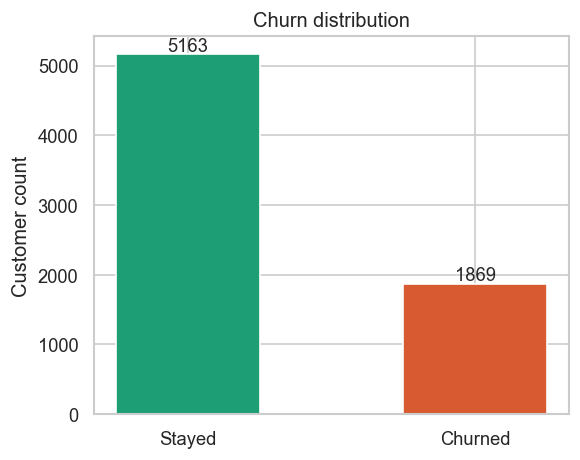

Churn rate: 26.6%


In [5]:
churn_counts = df["Churn"].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Stayed", "Churned"], churn_counts.values, color=["#1D9E75","#D85A30"], width=0.5)
ax.set_title("Churn distribution")
ax.set_ylabel("Customer count")

for i,v in enumerate(churn_counts.values):
    ax.text(i,v+50, str(v), ha="center",fontsize="11")

plt.tight_layout()
plt.show()
print(f"Churn rate: {df['Churn'].mean()*100:.1f}%")

> 26.6% churn rate — moderately imbalanced. 

## 3. Numerical Feature Distributions

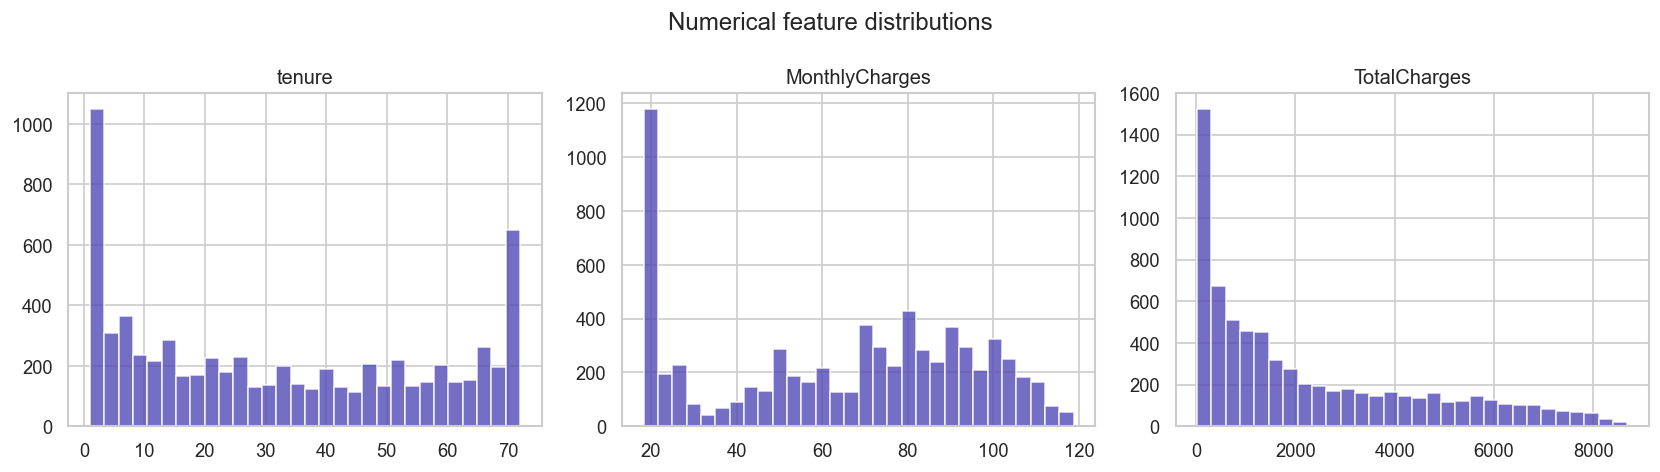

In [6]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig,axes = plt.subplots(1,3,figsize=(14,4))

for ax, col in zip(axes, num_cols):
    df[col].hist(bins=30,ax=ax,color="#534AB7",alpha=0.8)
    ax.set_title(col)

plt.suptitle("Numerical feature distributions")
plt.tight_layout()
plt.show()

## 4. Churn Rate by Contract & Internet Service

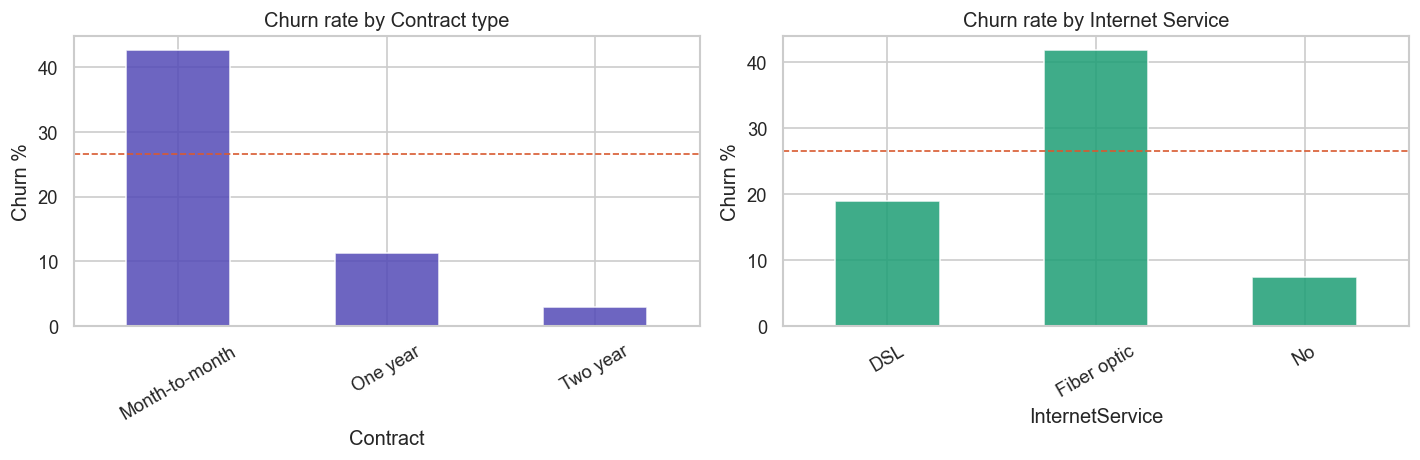

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contract_churn = df.groupby("Contract")["Churn"].mean() * 100
contract_churn.plot(kind="bar", ax=axes[0], color="#534AB7", alpha=0.85)
axes[0].set_title("Churn rate by Contract type")
axes[0].set_ylabel("Churn %")
axes[0].tick_params(axis="x", rotation=30)
axes[0].axhline(26.6, color="#D85A30", linestyle="--", linewidth=1)

internet_churn = df.groupby("InternetService")["Churn"].mean() * 100
internet_churn.plot(kind="bar", ax=axes[1], color="#1D9E75", alpha=0.85)
axes[1].set_title("Churn rate by Internet Service")
axes[1].set_ylabel("Churn %")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(26.6, color="#D85A30", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

> Month-to-month churn = **42.7%** vs two-year = **2.8%** | Fiber optic churn = **41.9%**

## 5. Numerical Features vs Churn

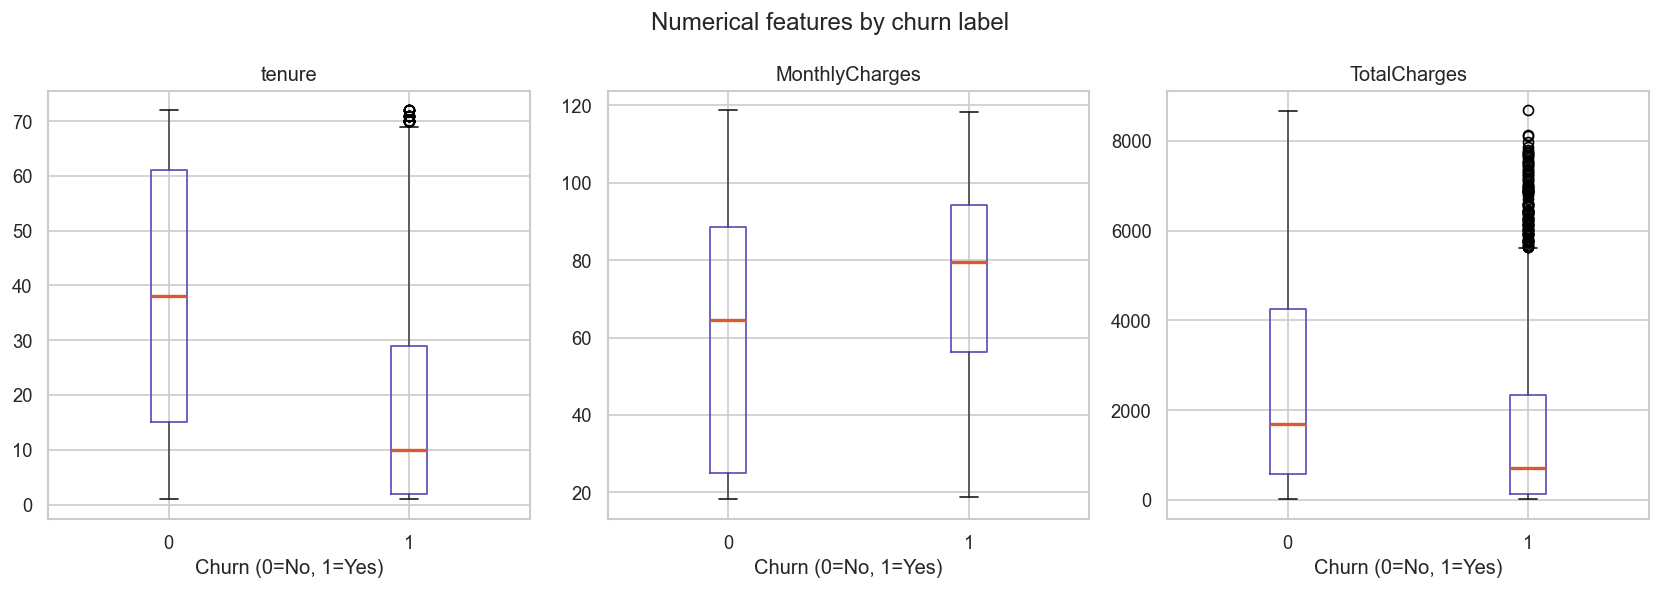

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by="Churn", ax=ax, boxprops=dict(color="#534AB7"), medianprops=dict(color="#D85A30", linewidth=2))
    ax.set_title(col)
    ax.set_xlabel("Churn (0=No, 1=Yes)")

plt.suptitle("Numerical features by churn label")
plt.tight_layout()
plt.show()

> Median tenure: churners ~10 months vs retained ~38 months

## 6. Feature Correlation with Churn

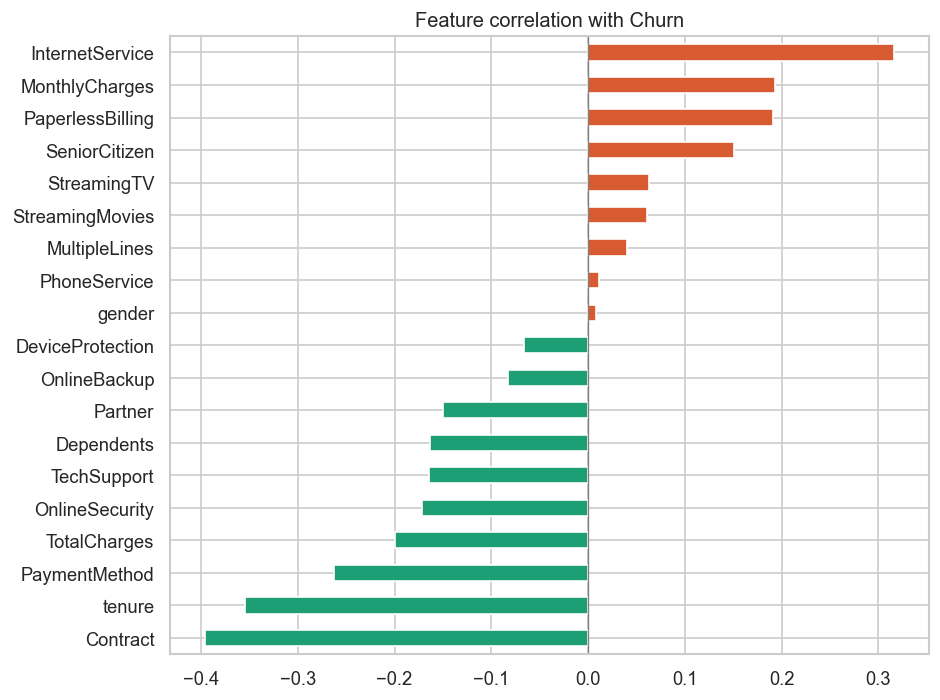

In [9]:
binary_cols = ["Partner", "Dependents", "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "PaperlessBilling"]

df_encoded = df.copy()

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({"Yes":1, "No":0, "No internet service":0, "No phone service":0})

df_encoded["Contract"] = df_encoded["Contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2})
df_encoded["InternetService"] = df_encoded["InternetService"].map({"No": 0, "DSL": 1, "Fiber optic": 2})
df_encoded["PaymentMethod"] = df_encoded["PaymentMethod"].map({"Electronic check": 0, "Mailed check": 1, "Bank transfer (automatic)": 2, "Credit card (automatic)": 3})
df_encoded["gender"] = df_encoded["gender"].map({"Male": 0, "Female": 1})


corr = df_encoded.corr()["Churn"].drop("Churn").sort_values()
colors = ["#D85A30" if v > 0 else "#1D9E75" for v in corr.values]

fig, ax = plt.subplots(figsize=(8, 6))
corr.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("Feature correlation with Churn")
plt.tight_layout()
plt.show()

> `Contract` (-0.39) and `tenure` (-0.35) are the strongest predictors. 

> `InternetService` (+0.33) is the surprise — fiber optic customers churn most. `MonthlyCharges` (+0.19) and `PaperlessBilling` (+0.19) also increase churn risk.

## 7. Save Clean Dataset

In [10]:
df_encoded.to_csv("../data/processed/telco_churn_clean.csv", index=False)
print("Saved! Shape:", df_encoded.shape)


Saved! Shape: (7032, 20)


## Key Findings

| Feature | Insight |
|---------|---------|
| Contract type | Strongest predictor — month-to-month churn 15× higher than 2-year |
| Tenure | Churners leave within first 10 months |
| Fiber optic | Highest churn despite premium pricing |
| Monthly charges | Higher charges → higher churn risk |

**Next → `02_feature_engineering.ipynb`**